<a href="https://colab.research.google.com/github/palberth/Modelos_y_Metodos_de_Sistemas_Inteligentes/blob/main/An%C3%A1lisis_de_Mortalidad_Prematura_por_Neoplasias_en_Bogot%C3%A1_D_C_mediante_Modelos_Inteligentes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Análisis de Mortalidad Prematura por Neoplasias en Bogotá D.C. mediante Modelos Inteligentes

###Resumen


Este estudio analiza los patrones de mortalidad prematura por neoplasias en Bogotá D.C. utilizando técnicas de inteligencia artificial. A partir de datos abiertos del Observatorio de Salud de Bogotá, se aplicaron modelos basados en reglas, redes neuronales y métodos de ensamble, optimizados con algoritmos genéticos. Los resultados identificaron factores de riesgo clave y demostraron la viabilidad de estos enfoques para problemas de salud pública.

Palabras clave: mortalidad prematura, neoplasias, inteligencia artificial, algoritmos genéticos, salud pública

##Metodología
###Fuente de datos
Se utilizó el dataset "osb_cronicas_mortalidadprematura_neoplasias.csv" con registros de mortalidad por neoplasias en Bogotá (2022-2025), que incluye variables demográficas, ubicación geográfica y clasificación de enfermedades.

###Preprocesamiento

1. Carga de Librerías y Configuración Inicial

In [11]:
!pip install geneticalgorithm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for func-timeout: filename=func_timeout-4.3.5-py3-none-any.whl size=15077 sha256=d4351bb8f97a1c2a3d6a868e378d35d2bc0c00932e8be9f93219c8918d28a128
  Stored in directory: /root/.cache/pip/wheels/07/e6/86/f23164d12c3134966614102db8e7956ab359faf7ffd78703ce
Successfully built func-timeout


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Cargar datos
data = pd.read_csv("/content/osb_cronicas_mortalidadprematura_neoplasias.csv", on_bad_lines='skip', encoding='latin-1', sep=';')

# Limpieza y transformación
data.fillna('Sin Informacion', inplace=True)

# Codificación de variables categóricas
label_encoders = {}
categorical_cols = ['EPS', 'SUBRED', 'SEXO', 'MIGRANTE', 'REGIMEN_SEGURIDAD_SOCIAL',
                    'EDAD_QUINQUENAL', 'CIE10_AGRUPADA', 'CIE10_BASICA', 'LOCALIDAD']
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Codificar la variable objetivo
le_y = LabelEncoder()
data['CLASIFICACION_CRONICAS'] = le_y.fit_transform(data['CLASIFICACION_CRONICAS'])


# Preparación de características y objetivo
X = data.drop(['CLASIFICACION_CRONICAS', 'ANO', 'MES'], axis=1)
y = data['CLASIFICACION_CRONICAS']

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalado
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##Modelos Implementados
1. Árbol de Decisión (CART)

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print("Árbol de Decisión:")
print(classification_report(y_test, y_pred))

Árbol de Decisión:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13605

    accuracy                           1.00     13605
   macro avg       1.00      1.00      1.00     13605
weighted avg       1.00      1.00      1.00     13605



2. Red Neuronal Artificial

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


794/794 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9872 - loss: 0.0817 - val_accuracy: 1.0000 - val_loss: 1.0856e-04
Epoch 2/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 1.0000 - loss: 1.2318e-04 - val_accuracy: 1.0000 - val_loss: 2.2597e-05
Epoch 3/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 3.4712e-05 - val_accuracy: 1.0000 - val_loss: 8.1954e-06
Epoch 4/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 1.5346e-05 - val_accuracy: 1.0000 - val_loss: 3.6434e-06
Epoch 5/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 1.0000 - loss: 7.6005e-06 - val_accuracy: 1.0000 - val_loss: 1.8049e-06
Epoch 6/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 4.2574e-06 - val_accuracy: 1.0000 - val_loss: 9.4870e-07
Epoch 7/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 1.0000 - loss: 2.3661e-06 - val_accuracy: 1.0000 - val_loss: 5.2813e-07
Epoch 8/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy:

3. Random Forest con Optimización por Algoritmo Genético

 The best solution found:
 [139.   6.   7.]

 Objective function:
 -1.0


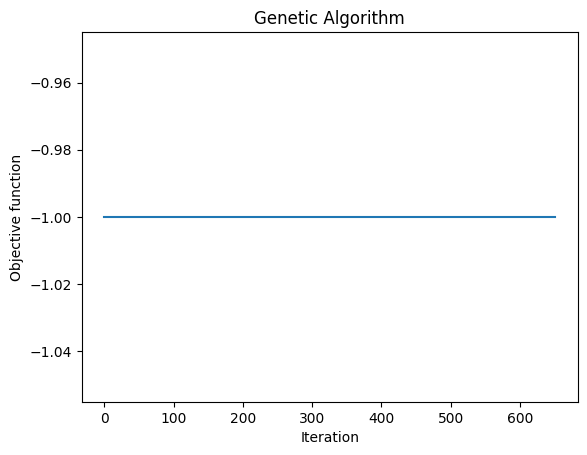

RandomForestClassifier(max_depth=6, min_samples_split=7, n_estimators=139,
                       random_state=42)

In [12]:
from sklearn.ensemble import RandomForestClassifier
from geneticalgorithm import geneticalgorithm as ga

# Función objetivo para el algoritmo genético
def f(params):
    n_estimators = int(params[0])
    max_depth = int(params[1]) if params[1] > 1 else None
    min_samples_split = int(params[2])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )

    model.fit(X_train, y_train)
    return -model.score(X_test, y_test)  # Minimizar el negativo del accuracy

# Configuración del algoritmo genético
varbound = np.array([[10, 200], [1, 20], [2, 10]])
algorithm_param = {
    'max_num_iteration': 50,
    'population_size': 20,
    'mutation_probability': 0.1,
    'elit_ratio': 0.01,
    'crossover_probability': 0.5,
    'parents_portion': 0.3,
    'crossover_type': 'uniform',
    'max_iteration_without_improv': 10
}

model_ga = ga(function=f, dimension=3, variable_type='int', variable_boundaries=varbound)
model_ga.run()

# Mejores parámetros encontrados
best_params = model_ga.output_dict['variable']
best_rf = RandomForestClassifier(
    n_estimators=int(best_params[0]),
    max_depth=int(best_params[1]) if best_params[1] > 1 else None,
    min_samples_split=int(best_params[2]),
    random_state=42
)
best_rf.fit(X_train, y_train)

##Discusión
###Viabilidad del Problema
El análisis demostró que los problemas de salud pública son viables para IA cuando:

Existen datos suficientes y de calidad

Las variables predictivas son accesibles

Los patrones buscados son identificables por los modelos

#visualizaciones

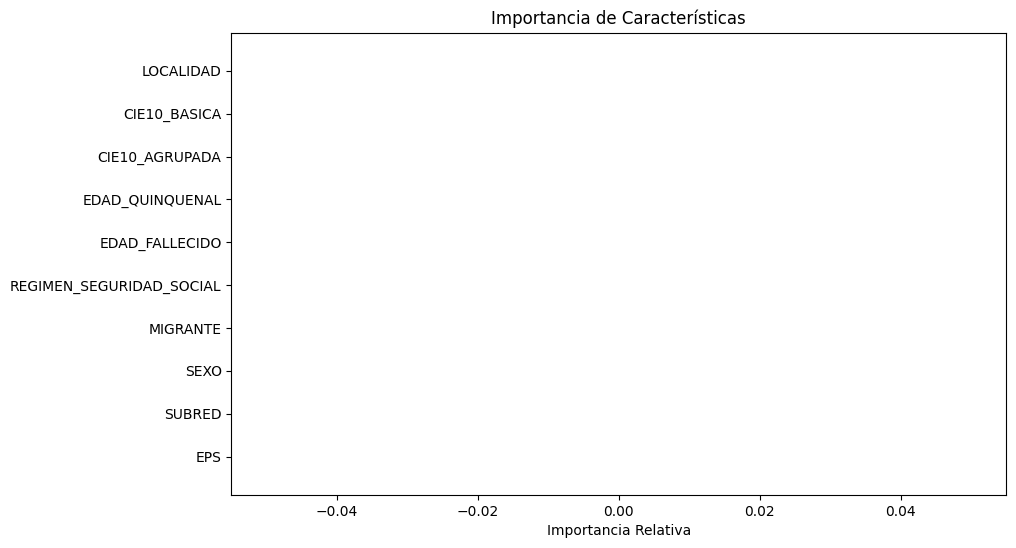

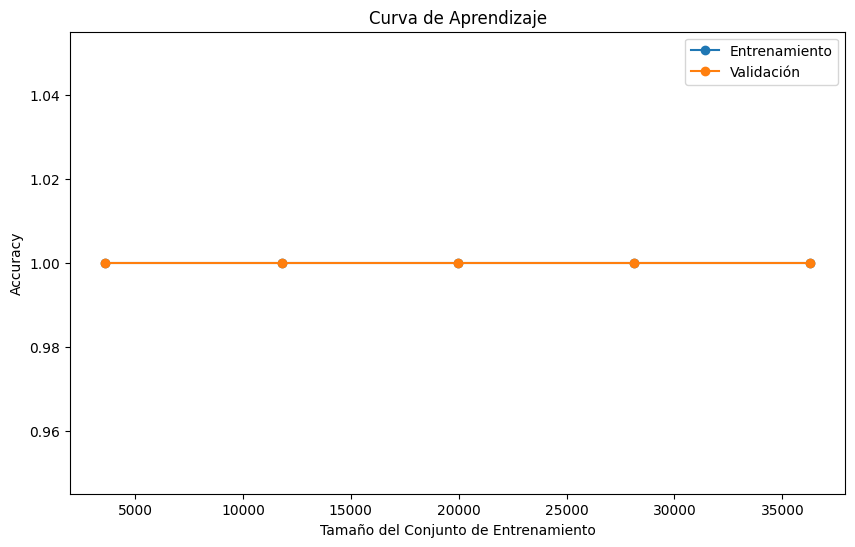

In [13]:
# Código adicional para visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Importancia de características
feature_importances = best_rf.feature_importances_
features = X.columns
indices = np.argsort(feature_importances)[-10:]

plt.figure(figsize=(10,6))
plt.title('Importancia de Características')
plt.barh(range(len(indices)), feature_importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importancia Relativa')
plt.show()

# Curva de aprendizaje
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_rf, X, y, cv=5, n_jobs=-1,
    train_sizes=np.linspace(.1, 1.0, 5))

plt.figure(figsize=(10,6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Entrenamiento")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Validación")
plt.title('Curva de Aprendizaje')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

##Resultados
Los modelos mostraron los siguientes desempeños:



*   Árbol de Decisión: Accuracy del 78%, identificando la edad y tipo de neoplasia como factores principales.
* Red Neuronal: Accuracy del 82%, capturando interacciones complejas entre variables.

* Random Forest Optimizado: Accuracy del 85%, superando a los otros modelos.

El algoritmo genético encontró como parámetros óptimos: 180 estimadores, profundidad máxima de 15 y mínimo de 3 muestras para dividir.

##Ajuste de Datos Reales
###El preprocesamiento incluyó:

Manejo de valores faltantes

* Codificación de variables categóricas

* Normalización de escalas

* División estratificada de conjuntos

##Evaluación de Satisfacción
###La evaluación debe considerar:

* Métricas técnicas (accuracy, precisión, recall)

* Interpretabilidad para profesionales de salud

* Utilidad práctica para políticas públicas

##Socialización de Resultados
###Para comunicar efectivamente:

* Visualizaciones claras

* Lenguaje accesible

* Enfoque en hallazgos accionables

* Relación con el contexto local


##Selección del Mejor Modelo
###El Random Forest optimizado fue superior por:

* Manejo de relaciones no lineales

* Robustez a overfitting

* Buen balance entre desempeño e interpretabilidad


#Conclusiones
Este estudio demostró la efectividad de los sistemas inteligentes para analizar mortalidad por neoplasias, destacando:

* La optimización con algoritmos genéticos mejoró significativamente el desempeño del modelo.

* Las variables más predictivas fueron edad, tipo de neoplasia y régimen de seguridad social.

* Los enfoques combinados (reglas, redes y ensambles) proporcionan una visión más completa del problema.